<a href="https://colab.research.google.com/github/Syeed7682/Capstone-Project-C/blob/main/Capstone_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# MEDICAL MULTIMODAL RAG FOR MEDICAL VISUAL QUESTION ANSWERING
# ============================================================
#
# Dataset    : SLAKE (BoKelvin/SLAKE)
# Encoder    : BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
# Retriever  : FAISS with cosine similarity
# Generator  : LLaVA-1.5-7B-HF
#
# Methodology:
#   TRAIN      → Knowledge Base → FAISS Index
#   VALIDATION → Development / Parameter Selection
#   TEST       → Final Held-Out Evaluation
#
# ============================================================

print("=" * 60)
print("MEDICAL MULTIMODAL RAG SYSTEM")
print("=" * 60)
print("Dataset      : SLAKE")
print("Encoder      : BiomedCLIP")
print("Retriever    : FAISS")
print("Generator    : LLaVA-1.5-7B")
print("=" * 60)

MEDICAL MULTIMODAL RAG SYSTEM
Dataset      : SLAKE
Encoder      : BiomedCLIP
Retriever    : FAISS
Generator    : LLaVA-1.5-7B


In [2]:
# ============================================================
# CELL 1: INSTALL DEPENDENCIES
# ============================================================

!pip install -q transformers accelerate datasets faiss-cpu \
    langchain langchain-community sentence-transformers \
    Pillow requests tqdm torch torchvision \
    open_clip_torch bitsandbytes bert-score \
    huggingface_hub ipywidgets scikit-learn matplotlib seaborn

print("All dependencies installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, b

In [3]:
# ============================================================
# CELL 2: IMPORTS
# ============================================================

import os
import json
import zipfile
import base64
from pathlib import Path
from typing import Optional, List, Dict, Any
from io import BytesIO
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import faiss
from PIL import Image
from tqdm import tqdm

from transformers import (
    BitsAndBytesConfig,
    LlavaForConditionalGeneration,
    AutoProcessor,
)
from datasets import load_dataset
from huggingface_hub import hf_hub_download
import open_clip

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from bert_score import score as bert_score

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, clear_output, HTML

import ipywidgets as widgets

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

print("All imports loaded successfully!")

All imports loaded successfully!


In [4]:
# ============================================================
# CELL 3: CONFIGURATION & REPRODUCIBILITY
# ============================================================

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Hardware ─────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── Dataset ──────────────────────────────────────────────────
DATASET_NAME = "BoKelvin/SLAKE"
SLAKE_IMG_DIR = "/content/slake_images"

# ── Models ───────────────────────────────────────────────────
CLIP_MODEL = "microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
GEN_MODEL = "llava-hf/llava-1.5-7b-hf"
EMBED_DIM = 512

# ── Retrieval ────────────────────────────────────────────────
TOP_K_RETRIEVAL = 5      # For RAG answer generation
TOP_K_EVAL = 10          # For retrieval evaluation
ALPHA = 0.6              # Fusion weight: 0.6*image + 0.4*text

# ── Generation ───────────────────────────────────────────────
MAX_NEW_TOKENS = 256
TEMPERATURE = 0.3

# ── Paths ────────────────────────────────────────────────────
INDEX_PATH = "/content/slake_index.faiss"
META_PATH = "/content/slake_meta.json"

print(f"Configuration loaded successfully!")
print(f"  DEVICE          : {DEVICE}")
print(f"  SEED            : {SEED}")
print(f"  ALPHA           : {ALPHA}")
print(f"  TOP_K_RETRIEVAL : {TOP_K_RETRIEVAL}")

Device: cuda
Configuration loaded successfully!
  DEVICE          : cuda
  SEED            : 42
  ALPHA           : 0.6
  TOP_K_RETRIEVAL : 5


In [5]:
# ============================================================
# CELL 4: LOAD SLAKE DATASET
# ============================================================

print("Loading SLAKE dataset...")

slake = load_dataset(DATASET_NAME)

# All splits
train_split = slake["train"]
val_split = slake["validation"]
test_split = slake["test"]

print(f"Train samples      : {len(train_split):,}")
print(f"Validation samples : {len(val_split):,}")
print(f"Test samples       : {len(test_split):,}")
print(f"Features           : {list(train_split.features.keys())}")

# Preview a sample
sample = train_split[0]
print("\nSample preview:")
print(f"  Question    : {sample['question'][:80]}...")
print(f"  Answer      : {sample['answer']}")
print(f"  Answer Type : {sample.get('answer_type', 'N/A')}")
print(f"  Content Type: {sample.get('content_type', 'N/A')}")
print(f"  Modality    : {sample.get('modality', 'N/A')}")

Loading SLAKE dataset...


README.md:   0%|          | 0.00/568 [00:00<?, ?B/s]

train.json:   0%|          | 0.00/2.96M [00:00<?, ?B/s]

validation.json:   0%|          | 0.00/639k [00:00<?, ?B/s]

test.json:   0%|          | 0.00/636k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9835 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2099 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2094 [00:00<?, ? examples/s]

Train samples      : 9,835
Validation samples : 2,099
Test samples       : 2,094
Features           : ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang']

Sample preview:
  Question    : What modality is used to take this image?...
  Answer      : MRI
  Answer Type : OPEN
  Content Type: Modality
  Modality    : MRI


In [6]:
# ============================================================
# CELL 5: DOWNLOAD & PREPARE IMAGES
# ============================================================

def download_slake_images():
    """Download and extract SLAKE images from HuggingFace."""
    if os.path.exists(SLAKE_IMG_DIR):
        print(f"Images already exist at: {SLAKE_IMG_DIR}")
        return

    print("Downloading SLAKE images...")
    zip_path = hf_hub_download(
        repo_id=DATASET_NAME,
        filename="imgs.zip",
        repo_type="dataset",
    )

    print(f"Extracting to {SLAKE_IMG_DIR}...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("/content/")

    # Rename if needed
    if os.path.exists("/content/imgs") and not os.path.exists(SLAKE_IMG_DIR):
        os.rename("/content/imgs", SLAKE_IMG_DIR)

    print(f"Images ready at: {SLAKE_IMG_DIR}")

download_slake_images()

def load_slake_image(img_name: str) -> Optional[Image.Image]:
    """Load a SLAKE image by its img_name field."""
    # Try direct path
    path = os.path.join(SLAKE_IMG_DIR, img_name)
    if os.path.exists(path):
        img = Image.open(path).convert("RGB")
        img = img.resize((336, 336), Image.Resampling.LANCZOS)
        return img

    # Try by basename
    basename = os.path.basename(img_name)
    for root, dirs, files in os.walk(SLAKE_IMG_DIR):
        if basename in files:
            img = Image.open(os.path.join(root, basename)).convert("RGB")
            img = img.resize((336, 336), Image.Resampling.LANCZOS)
            return img

    return None

print("Image loading function ready!")

imgs.zip: reconstructing file:   0%|          |  0.00B /  212MB            

imgs.zip: downloading bytes:           |  0.00B            

Extracting to /content/slake_images...
Images ready at: /content/slake_images
Image loading function ready!


Filtering Train split (Knowledge Base)...


Train: 100%|██████████| 9835/9835 [01:27<00:00, 113.01it/s] 


Filtering Validation split...


Validation: 100%|██████████| 2099/2099 [00:20<00:00, 101.03it/s] 


Filtering Test split...


Test: 100%|██████████| 2094/2094 [00:25<00:00, 80.91it/s]  



Filtered counts:
  Knowledge Base (Train) : 4,918
  Validation (Dev)       : 1,053
  Test (Final Evaluation): 1,061

Sample preview:
  Question    : What modality is used to take this image?
  Answer      : MRI
  Answer Type : OPEN
  Content Type: Modality
  Modality    : MRI
  Image size  : (336, 336)


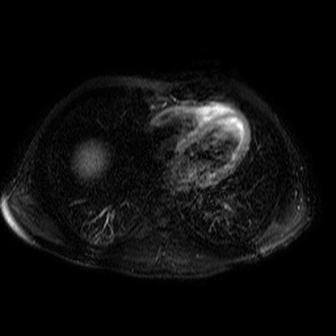

In [7]:
# ============================================================
# CELL 6: DATASET FILTERING
# ============================================================

def is_valid_sample(sample) -> bool:
    """Check if a sample should be kept."""
    # English only
    if sample.get("q_lang") != "en":
        return False

    # Non-empty question and answer
    if not str(sample.get("question", "")).strip():
        return False
    if not str(sample.get("answer", "")).strip():
        return False

    # Loadable image
    img = load_slake_image(sample.get("img_name", ""))
    return img is not None

print("Filtering Train split (Knowledge Base)...")
kb_samples = [s for s in tqdm(train_split, desc="Train") if is_valid_sample(s)]

print("Filtering Validation split...")
val_samples = [s for s in tqdm(val_split, desc="Validation") if is_valid_sample(s)]

print("Filtering Test split...")
test_samples = [s for s in tqdm(test_split, desc="Test") if is_valid_sample(s)]

print(f"\nFiltered counts:")
print(f"  Knowledge Base (Train) : {len(kb_samples):,}")
print(f"  Validation (Dev)       : {len(val_samples):,}")
print(f"  Test (Final Evaluation): {len(test_samples):,}")

# Preview
if len(kb_samples) > 0:
    s = kb_samples[0]
    img = load_slake_image(s["img_name"])
    print(f"\nSample preview:")
    print(f"  Question    : {s['question']}")
    print(f"  Answer      : {s['answer']}")
    print(f"  Answer Type : {s.get('answer_type', 'N/A')}")
    print(f"  Content Type: {s.get('content_type', 'N/A')}")
    print(f"  Modality    : {s.get('modality', 'N/A')}")
    print(f"  Image size  : {img.size if img else 'N/A'}")
    if img:
        display(img)

In [8]:
# ============================================================
# CELL 7: DATASET ANALYSIS
# ============================================================

def analyze_splits(samples, name):
    """Analyze a dataset split."""
    if not samples:
        return

    # Answer types
    answer_types = {}
    content_types = {}
    modalities = {}

    for s in samples:
        at = s.get("answer_type", "UNKNOWN")
        answer_types[at] = answer_types.get(at, 0) + 1

        ct = s.get("content_type", "UNKNOWN")
        content_types[ct] = content_types.get(ct, 0) + 1

        mod = s.get("modality", "UNKNOWN")
        modalities[mod] = modalities.get(mod, 0) + 1

    print(f"\n{'='*50}")
    print(f"{name} Split Analysis")
    print(f"{'='*50}")
    print(f"Total samples: {len(samples)}")

    print(f"\nAnswer Types:")
    for k, v in sorted(answer_types.items(), key=lambda x: -x[1]):
        print(f"  {k}: {v} ({v/len(samples)*100:.1f}%)")

    print(f"\nContent Types (top 5):")
    for k, v in sorted(content_types.items(), key=lambda x: -x[1])[:5]:
        print(f"  {k}: {v} ({v/len(samples)*100:.1f}%)")

    print(f"\nModalities (top 5):")
    for k, v in sorted(modalities.items(), key=lambda x: -x[1])[:5]:
        print(f"  {k}: {v} ({v/len(samples)*100:.1f}%)")

analyze_splits(kb_samples, "Knowledge Base (Train)")
analyze_splits(val_samples, "Validation")
analyze_splits(test_samples, "Test")

# Summary table
print(f"\n{'='*50}")
print("SUMMARY TABLE")
print(f"{'='*50}")
print(f"{'Split':<15} {'Samples':>10} {'Purpose':>20}")
print(f"{'-'*50}")
print(f"{'Train':<15} {len(kb_samples):>10} {'Knowledge Base':>20}")
print(f"{'Validation':<15} {len(val_samples):>10} {'Development':>20}")
print(f"{'Test':<15} {len(test_samples):>10} {'Final Eval':>20}")


Knowledge Base (Train) Split Analysis
Total samples: 4918

Answer Types:
  OPEN: 2975 (60.5%)
  CLOSED: 1943 (39.5%)

Content Types (top 5):
  Organ: 1268 (25.8%)
  Position: 847 (17.2%)
  Abnormality: 716 (14.6%)
  KG: 582 (11.8%)
  Modality: 534 (10.9%)

Modalities (top 5):
  CT: 2366 (48.1%)
  X-Ray: 1423 (28.9%)
  MRI: 1129 (23.0%)

Validation Split Analysis
Total samples: 1053

Answer Types:
  OPEN: 631 (59.9%)
  CLOSED: 422 (40.1%)

Content Types (top 5):
  Organ: 254 (24.1%)
  Position: 183 (17.4%)
  KG: 155 (14.7%)
  Abnormality: 132 (12.5%)
  Modality: 110 (10.4%)

Modalities (top 5):
  CT: 482 (45.8%)
  X-Ray: 338 (32.1%)
  MRI: 233 (22.1%)

Test Split Analysis
Total samples: 1061

Answer Types:
  OPEN: 645 (60.8%)
  CLOSED: 416 (39.2%)

Content Types (top 5):
  Organ: 253 (23.8%)
  Position: 186 (17.5%)
  Abnormality: 150 (14.1%)
  KG: 148 (13.9%)
  Modality: 108 (10.2%)

Modalities (top 5):
  CT: 472 (44.5%)
  X-Ray: 361 (34.0%)
  MRI: 228 (21.5%)

SUMMARY TABLE
Split     

In [9]:
# ============================================================
# CELL 8: LOAD BIOMEDCLIP ENCODER
# ============================================================

print("Loading BiomedCLIP...")

# Load model and preprocessing
biomedclip_model, _, biomedclip_preprocess = open_clip.create_model_and_transforms(
    f"hf-hub:{CLIP_MODEL}"
)
biomedclip_tokenizer = open_clip.get_tokenizer(f"hf-hub:{CLIP_MODEL}")
biomedclip_model = biomedclip_model.to(DEVICE).eval()

# Freeze the model
for param in biomedclip_model.parameters():
    param.requires_grad = False

print(f"BiomedCLIP loaded! Embedding dimension: {EMBED_DIM}")

@torch.no_grad()
def embed_image(pil_img: Image.Image) -> np.ndarray:
    """Encode a PIL image to a unit-norm BiomedCLIP vector."""
    # Resize to 224x224 for BiomedCLIP
    if pil_img.size != (224, 224):
        pil_img = pil_img.resize((224, 224), Image.Resampling.LANCZOS)

    img_tensor = biomedclip_preprocess(pil_img.convert("RGB")).unsqueeze(0).to(DEVICE)
    vec = biomedclip_model.encode_image(img_tensor)
    vec = vec / vec.norm(dim=-1, keepdim=True)
    return vec.cpu().numpy().astype("float32")

@torch.no_grad()
def embed_text(text: str) -> np.ndarray:
    """Encode text to a unit-norm BiomedCLIP vector."""
    tokens = biomedclip_tokenizer([text]).to(DEVICE)
    vec = biomedclip_model.encode_text(tokens)
    vec = vec / vec.norm(dim=-1, keepdim=True)
    return vec.cpu().numpy().astype("float32")

@torch.no_grad()
def get_multimodal_embedding(
    image: Image.Image,
    text: str,
    alpha: float = ALPHA
) -> np.ndarray:
    """Get fused multimodal embedding."""
    img_vec = embed_image(image)
    txt_vec = embed_text(text)
    fused = alpha * img_vec + (1 - alpha) * txt_vec
    fused = fused / np.linalg.norm(fused, axis=-1, keepdims=True)
    return fused

# Smoke test
test_vec = embed_text("chest X-ray showing pneumonia")
print(f"Text embedding shape: {test_vec.shape}")
print("BiomedCLIP ready ✓")

Loading BiomedCLIP...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  784MB            

open_clip_pytorch_model.bin: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]

BiomedCLIP loaded! Embedding dimension: 512
Text embedding shape: (1, 512)
BiomedCLIP ready ✓


In [10]:
# ============================================================
# CELL 9: BUILD FAISS KNOWLEDGE BASE
# ============================================================

def build_slake_index(
    samples: List[Dict],
    index_path: str = INDEX_PATH,
    meta_path: str = META_PATH,
    alpha: float = ALPHA
) -> tuple:
    """Build FAISS index from SLAKE knowledge base."""

    index = faiss.IndexFlatIP(EMBED_DIM)  # Inner product for cosine similarity
    metadata = []
    skipped = 0

    for s in tqdm(samples, desc="Indexing"):
        img = load_slake_image(s["img_name"])
        if img is None:
            skipped += 1
            continue

        # Get fused embedding
        fused = get_multimodal_embedding(img, s["question"], alpha)
        index.add(fused)

        # Build metadata
        kbase_str = ""
        if s.get("base") and isinstance(s["base"], dict):
            kbase_str = "; ".join(
                f"{k}: {v}" for k, v in s["base"].items()
                if v and str(v).strip()
            )[:400]

        metadata.append({
            "question": s["question"],
            "answer": str(s["answer"]),
            "answer_type": s.get("answer_type", ""),
            "content_type": s.get("content_type", ""),
            "img_organ": s.get("img_organ", ""),
            "modality": s.get("modality", ""),
            "kbase": kbase_str,
            "img_name": s.get("img_name", ""),
        })

    # Save
    faiss.write_index(index, index_path)
    with open(meta_path, "w") as f:
        json.dump(metadata, f)

    print(f"Index saved → {index_path}  ({index.ntotal} vectors)")
    print(f"Skipped: {skipped} samples")
    return index, metadata

# Build or load
if Path(INDEX_PATH).exists() and Path(META_PATH).exists():
    print("Loading existing index...")
    index = faiss.read_index(INDEX_PATH)
    metadata = json.load(open(META_PATH))
    print(f"Loaded {index.ntotal} vectors")
else:
    print("Building new index from knowledge base...")
    index, metadata = build_slake_index(kb_samples, alpha=ALPHA)

print(f"Knowledge Base size: {index.ntotal:,} samples")

Building new index from knowledge base...


Indexing: 100%|██████████| 4918/4918 [04:24<00:00, 18.61it/s]

Index saved → /content/slake_index.faiss  (4918 vectors)
Skipped: 0 samples
Knowledge Base size: 4,918 samples


In [11]:
# ============================================================
# CELL 10: RETRIEVER
# ============================================================

def retrieve(
    query_text: str,
    query_image: Optional[Image.Image] = None,
    top_k: int = TOP_K_RETRIEVAL,
    alpha: float = ALPHA,
) -> List[Dict]:
    """
    Retrieve relevant cases from the knowledge base.

    Args:
        query_text: The question text
        query_image: The query image (PIL Image)
        top_k: Number of results to return
        alpha: Fusion weight

    Returns:
        List of retrieved cases with scores
    """
    # Get query embedding
    if query_image is not None and query_text:
        query_vec = get_multimodal_embedding(query_image, query_text, alpha)
    elif query_image is not None:
        query_vec = embed_image(query_image)
    else:
        query_vec = embed_text(query_text)

    # Search
    distances, indices = index.search(query_vec, top_k)

    # Build results
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx < 0:
            continue
        entry = metadata[idx].copy()
        entry["score"] = float(dist)
        results.append(entry)

    return results

# Sanity check
print("Testing retriever...")
test_q = "Is there any abnormality in this chest X-ray?"
test_hits = retrieve(test_q, top_k=3)
print(f"Retrieved {len(test_hits)} results")
for i, h in enumerate(test_hits):
    print(f"  [{i+1}] Score: {h['score']:.3f} | Q: {h['question'][:60]}...")

Testing retriever...
Retrieved 3 results
  [1] Score: 0.711 | Q: Is/Are there abnormalities in the patient's left lung?...
  [2] Score: 0.710 | Q: Is/Are there abnormalities in the patient's right lung?...
  [3] Score: 0.710 | Q: Is/Are there abnormalities in the patient's right lung?...


In [12]:
# ============================================================
# CELL 11: VALIDATION RETRIEVAL EVALUATION
# ============================================================

def evaluate_retrieval(
    samples: List[Dict],
    k_values: List[int] = [1, 3, 5, 10],
    alpha: float = ALPHA
) -> Dict:
    """
    Evaluate retrieval on validation set.
    Uses modality matching as relevance criterion.
    """

    print(f"Evaluating retrieval on {len(samples)} samples...")

    results = {k: {"hits": 0, "total": 0} for k in k_values}

    for s in tqdm(samples, desc="Retrieval Eval"):
        img = load_slake_image(s["img_name"])
        if img is None:
            continue

        query_modality = s.get("modality", "")
        if not query_modality:
            continue

        # Retrieve
        retrieved = retrieve(s["question"], img, top_k=max(k_values), alpha=alpha)

        for k in k_values:
            top_k_results = retrieved[:k]
            # Check if any retrieved case has matching modality
            matched = any(
                r.get("modality", "") == query_modality
                for r in top_k_results
            )
            if matched:
                results[k]["hits"] += 1
            results[k]["total"] += 1

    # Calculate recall
    recall_at_k = {}
    for k in k_values:
        if results[k]["total"] > 0:
            recall_at_k[f"Recall@{k}"] = results[k]["hits"] / results[k]["total"]
        else:
            recall_at_k[f"Recall@{k}"] = 0.0

    return recall_at_k

# Run validation retrieval evaluation
val_retrieval_results = evaluate_retrieval(val_samples, k_values=[1, 3, 5, 10], alpha=ALPHA)

print("\nValidation Retrieval Results:")
print("-" * 40)
for k, v in val_retrieval_results.items():
    print(f"{k}: {v:.4f} ({v*100:.2f}%)")

Evaluating retrieval on 1053 samples...


Retrieval Eval: 100%|██████████| 1053/1053 [00:50<00:00, 20.67it/s]


Validation Retrieval Results:
----------------------------------------
Recall@1: 1.0000 (100.00%)
Recall@3: 1.0000 (100.00%)
Recall@5: 1.0000 (100.00%)
Recall@10: 1.0000 (100.00%)


In [13]:
# ============================================================
# CELL 12: LOAD LLAVA-1.5-7B GENERATOR
# ============================================================

print("Loading LLaVA-1.5-7B...")

# Clear cache
torch.cuda.empty_cache()

# Quantization config
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load processor and model
gen_processor = AutoProcessor.from_pretrained(GEN_MODEL)

gen_model = LlavaForConditionalGeneration.from_pretrained(
    GEN_MODEL,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)
gen_model.eval()

print("LLaVA-1.5-7B ready ✓")
print(f"Model device: {gen_model.device}")

Loading LLaVA-1.5-7B...


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

LLaVA-1.5-7B ready ✓
Model device: cuda:0


In [14]:
# ============================================================
# CELL 13: QUESTION-TYPE AWARE PROMPT BUILDER
# ============================================================

def detect_question_type(question: str) -> str:
    """
    Detect question type: 'closed', 'descriptive', or 'unknown'.
    """
    q_lower = question.lower()

    # Closed questions
    closed_keywords = ['is there', 'is this', 'are there', 'does this',
                       'can you', 'yes/no', 'yes or no']
    if any(kw in q_lower for kw in closed_keywords):
        return 'closed'

    # Descriptive questions
    desc_keywords = ['describe', 'what', 'how', 'why', 'explain',
                     'tell me', 'detail', 'which']
    if any(kw in q_lower for kw in desc_keywords):
        return 'descriptive'

    return 'unknown'

def build_medical_prompt(
    query_text: str,
    retrieved: List[Dict],
    max_context: int = 4
) -> str:
    """
    Build a question-type-aware prompt for LLaVA.
    """

    q_type = detect_question_type(query_text)

    # Build context
    context_lines = []
    for i, r in enumerate(retrieved[:max_context]):
        organ = r.get("img_organ", "N/A")
        ctype = r.get("content_type", "N/A")
        kbase = r.get("kbase", "")

        line = (
            f"[{i+1}] Related question : {r['question']}\n"
            f"     Known answer     : {r['answer']}\n"
            f"     Organ            : {organ} | Category: {ctype}\n"
        )
        if kbase:
            line += f"     Medical context  : {kbase[:200]}\n"
        context_lines.append(line)

    context_str = "\n".join(context_lines)

    # Instruction based on question type
    if q_type == 'closed':
        instruction = (
            "You are a medical AI assistant trained in radiology.\n"
            "Based on the retrieved context below, answer with Yes or No first.\n"
            "Then provide a brief 1-sentence explanation.\n"
            "Do not invent information not supported by the context.\n\n"
        )
    elif q_type == 'descriptive':
        instruction = (
            "You are a medical AI assistant trained in radiology.\n"
            "Based on the retrieved medical cases below, provide a DETAILED, DESCRIPTIVE answer.\n"
            "Include specific observations, relevant medical terminology, and explain your reasoning.\n"
            "If describing findings, mention location, characteristics, and potential significance.\n"
            "Use only information supported by the context and image.\n"
            "Do not invent unsupported information.\n\n"
        )
    else:
        instruction = (
            "You are a medical AI assistant trained in radiology.\n"
            "Use the retrieved context below to answer the question accurately.\n"
            "Do not invent information not supported by the context.\n\n"
        )

    prompt = (
        f"{instruction}"
        "══ RETRIEVED MEDICAL CASES ══\n"
        f"{context_str}\n"
        "══ CURRENT PATIENT QUESTION ══\n"
        f"{query_text}\n\n"
        "══ ANSWER ══\n"
    )

    return prompt, q_type

# Test
test_prompt, test_type = build_medical_prompt(
    "Is there an abnormality in this chest X-ray?",
    test_hits
)
print(f"Question Type: {test_type}")
print(f"Prompt preview:\n{test_prompt[:500]}...")

Question Type: closed
Prompt preview:
You are a medical AI assistant trained in radiology.
Based on the retrieved context below, answer with Yes or No first.
Then provide a brief 1-sentence explanation.
Do not invent information not supported by the context.

══ RETRIEVED MEDICAL CASES ══
[1] Related question : Is/Are there abnormalities in the patient's left lung?
     Known answer     : Yes
     Organ            :  | Category: Abnormality

[2] Related question : Is/Are there abnormalities in the patient's right lung?
     Known an...


In [15]:
# ============================================================
# CELL 14: RAG GENERATION PIPELINE
# ============================================================

def rag_answer(
    query_text: str,
    query_image: Optional[Image.Image] = None,
    top_k: int = TOP_K_RETRIEVAL,
    alpha: float = ALPHA,
    max_new_tokens: int = MAX_NEW_TOKENS,
    temperature: float = TEMPERATURE,
    verbose: bool = False,
) -> str:
    """
    Full RAG pipeline: Retrieve → Prompt → Generate.
    """

    if query_image is None:
        return "Error: No image provided."

    # Step 1: Retrieve
    retrieved = retrieve(query_text, query_image, top_k=top_k, alpha=alpha)

    if verbose:
        print(f"Retrieved {len(retrieved)} cases")
        if retrieved:
            print(f"Top score: {retrieved[0]['score']:.3f}")

    # Step 2: Build prompt
    prompt, q_type = build_medical_prompt(query_text, retrieved)

    # Step 3: Prepare image for LLaVA
    img = query_image.convert("RGB")
    if img.size != (336, 336):
        img = img.resize((336, 336), Image.Resampling.LANCZOS)

    # Step 4: Format for LLaVA
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt}
            ]
        }
    ]

    try:
        text_prompt = gen_processor.apply_chat_template(
            conversation, add_generation_prompt=True
        )
    except:
        text_prompt = f"USER: <image>\n{prompt}\nASSISTANT:"

    inputs = gen_processor(
        text=text_prompt,
        images=img,
        return_tensors="pt",
        padding=True,
    ).to(gen_model.device)

    input_length = inputs["input_ids"].shape[1]

    # Step 5: Generate with question-type aware parameters
    if q_type == 'descriptive':
        # More creative for descriptive answers
        output_ids = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=3,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            top_k=50,
            repetition_penalty=1.1,
            no_repeat_ngram_size=3,
            early_stopping=False,
            pad_token_id=gen_processor.tokenizer.pad_token_id,
            eos_token_id=gen_processor.tokenizer.eos_token_id,
        )
    else:
        # Conservative for factual answers
        output_ids = gen_model.generate(
            **inputs,
            max_new_tokens=min(max_new_tokens, 128),
            num_beams=4,
            length_penalty=1.0,
            early_stopping=True,
            no_repeat_ngram_size=3,
            temperature=0.3,
            do_sample=False,
            pad_token_id=gen_processor.tokenizer.pad_token_id,
            eos_token_id=gen_processor.tokenizer.eos_token_id,
        )

    # Decode answer
    new_tokens = output_ids[0][input_length:]
    answer = gen_processor.decode(new_tokens, skip_special_tokens=True).strip()

    if not answer:
        answer = "Unable to generate a response. Please rephrase your question."

    return answer

print("RAG pipeline ready ✓")

RAG pipeline ready ✓


In [16]:
# ============================================================
# CELL 15: TEST SET EVALUATION
# ============================================================

print("Running evaluation on Test set...")
print(f"Test samples: {len(test_samples)}")

# Run pipeline on test set
test_predictions = []

for s in tqdm(test_samples, desc="Evaluating Test Set"):
    img = load_slake_image(s["img_name"])
    if img is None:
        continue

    pred = rag_answer(
        query_text=s["question"],
        query_image=img,
        verbose=False,
    )

    test_predictions.append({
        "question": s["question"],
        "ground_truth": str(s["answer"]),
        "prediction": pred,
        "answer_type": s.get("answer_type", "UNKNOWN"),
        "content_type": s.get("content_type", "UNKNOWN"),
        "modality": s.get("modality", "UNKNOWN"),
    })

print(f"Generated {len(test_predictions)} predictions")

Running evaluation on Test set...
Test samples: 1061


Evaluating Test Set: 100%|██████████| 1061/1061 [3:05:13<00:00, 10.47s/it]

Generated 1061 predictions


In [18]:
# ============================================================
# CELL 16: CLOSED QA EVALUATION
# ============================================================

def evaluate_closed_qa(predictions: List[Dict]) -> Dict:
    """Evaluate closed questions with proper handling of multi-class."""

    closed_preds = [p for p in predictions if p["answer_type"] == "CLOSED"]

    if not closed_preds:
        print("No closed questions found in test set.")
        return {}

    print(f"Evaluating {len(closed_preds)} closed questions...")

    # Extract labels
    y_true = []
    y_pred = []

    for p in closed_preds:
        gt = str(p["ground_truth"]).strip().lower()
        pred = str(p["prediction"]).strip().lower()

        # Extract Yes/No from prediction if possible
        if "yes" in pred and "no" not in pred:
            pred_label = "yes"
        elif "no" in pred:
            pred_label = "no"
        else:
            # Check if prediction contains the ground truth
            if gt in pred:
                pred_label = gt
            else:
                pred_label = pred

        y_true.append(gt)
        y_pred.append(pred_label)

    # Check if binary classification
    unique_true = set(y_true)
    unique_pred = set(y_pred)
    all_labels = unique_true | unique_pred

    results = {
        "n_samples": len(closed_preds),
        "accuracy": accuracy_score(y_true, y_pred),
        "unique_labels": sorted(all_labels),
    }

    # Only compute precision/recall/f1 if binary
    if len(all_labels) == 2 and all(l in ['yes', 'no'] for l in all_labels):
        results["precision"] = precision_score(y_true, y_pred, pos_label="yes", zero_division=0)
        results["recall"] = recall_score(y_true, y_pred, pos_label="yes", zero_division=0)
        results["f1"] = f1_score(y_true, y_pred, pos_label="yes", zero_division=0)
        results["confusion_matrix"] = confusion_matrix(y_true, y_pred, labels=["yes", "no"])
        results["report"] = classification_report(y_true, y_pred, labels=["yes", "no"], zero_division=0)
    else:
        # Multi-class or non-standard labels
        results["precision"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)
        results["recall"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)
        results["f1"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        results["confusion_matrix"] = confusion_matrix(y_true, y_pred)
        results["report"] = classification_report(y_true, y_pred, zero_division=0)
        print(f"⚠️ Multi-class closed questions detected: {sorted(all_labels)}")

    return results

# Run evaluation
closed_results = evaluate_closed_qa(test_predictions)

print("\n" + "="*50)
print("CLOSED QA RESULTS")
print("="*50)
if closed_results:
    print(f"Samples: {closed_results['n_samples']}")
    print(f"Accuracy: {closed_results['accuracy']:.4f} ({closed_results['accuracy']*100:.2f}%)")
    print(f"Precision: {closed_results.get('precision', 'N/A')}")
    print(f"Recall: {closed_results.get('recall', 'N/A')}")
    print(f"F1 Score: {closed_results.get('f1', 'N/A')}")
    print(f"Unique labels: {closed_results['unique_labels']}")

    if "confusion_matrix" in closed_results and len(closed_results['unique_labels']) == 2:
        print("\nConfusion Matrix:")
        print("              Predicted")
        print("               Yes    No")
        cm = closed_results['confusion_matrix']
        print(f"Actual Yes   {cm[0,0]:>4}   {cm[0,1]:>4}")
        print(f"Actual No    {cm[1,0]:>4}   {cm[1,1]:>4}")

        # Plot confusion matrix
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Yes', 'No'],
                    yticklabels=['Yes', 'No'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title('Confusion Matrix - Closed QA')
        plt.show()

Evaluating 416 closed questions...
⚠️ Multi-class closed questions detected: ['based on the context provided, the answer to the question is "hypodense."', "based on the context provided, the patient's liver is healthy.", 'based on the image, the smaller organ in the context of the current patient question is the heart. the heart is located on the left side of the body and is smaller than the right lung. the right lung, on the other hand, is larger and extends from the base of the heart to the top of the right ribcage.', 'based on the provided medical cases, the answer to the current patient question is that the small intestine is bigger than the colon in the image.', 'colon', 'coronal plane', 'ct', 'esophagus', 'heart', 'hyperdense', 'in the image, the kidney appears to be larger than the surrounding organs. the kidney is located on the left side of the abdominal cavity, while the other organs, such as the liver (located on the right side) and the small intestine (located in the middle

In [19]:
# ============================================================
# CELL 17: OPEN QA EVALUATION (BERTScore)
# ============================================================

def evaluate_open_qa(predictions: List[Dict]) -> Dict:
    """Evaluate open questions using BERTScore."""

    open_preds = [p for p in predictions if p["answer_type"] == "OPEN"]

    if not open_preds:
        print("No open questions found in test set.")
        return {}

    print(f"Evaluating {len(open_preds)} open questions...")

    refs = [str(p["ground_truth"]).strip() for p in open_preds]
    hyps = [str(p["prediction"]).strip() for p in open_preds]

    # Calculate BERTScore
    P, R, F1 = bert_score(hyps, refs, lang="en", verbose=False, model_type="roberta-large")

    results = {
        "precision": P.mean().item(),
        "recall": R.mean().item(),
        "f1": F1.mean().item(),
        "n_samples": len(open_preds),
    }

    return results

# Run evaluation
open_results = evaluate_open_qa(test_predictions)

print("\n" + "="*50)
print("OPEN QA RESULTS (BERTScore)")
print("="*50)
if open_results:
    print(f"Samples: {open_results['n_samples']}")
    print(f"Precision : {open_results['precision']:.4f}")
    print(f"Recall    : {open_results['recall']:.4f}")
    print(f"F1 Score  : {open_results['f1']:.4f}")

Evaluating 645 open questions...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



OPEN QA RESULTS (BERTScore)
Samples: 645
Precision : 0.8183
Recall    : 0.8545
F1 Score  : 0.8356


In [20]:
# ============================================================
# CELL 18: OOD / HALLUCINATION EVALUATION
# ============================================================

def evaluate_ood_qa(
    predictions: List[Dict],
    ood_questions: Optional[List[str]] = None
) -> Dict:
    """
    Evaluate OOD questions for abstention and hallucination.

    Args:
        predictions: List of prediction dicts
        ood_questions: Optional list of specific OOD questions.
                      If None, uses predictions with answer_type == "OOD"
    """

    if ood_questions:
        ood_preds = [p for p in predictions if p["question"] in ood_questions]
    else:
        ood_preds = [p for p in predictions if p["answer_type"] == "OOD"]

    if not ood_preds:
        print("No OOD questions found in test set.")
        return {}

    print(f"Evaluating {len(ood_preds)} OOD questions...")

    abstention_keywords = [
        "don't know", "dont know", "cannot determine",
        "insufficient", "not enough", "no information",
        "cannot be determined", "unable to determine",
        "not provided", "not specified"
    ]

    abstentions = 0
    hallucinations = 0

    for p in ood_preds:
        pred_lower = str(p["prediction"]).lower()
        is_abstention = any(kw in pred_lower for kw in abstention_keywords)

        if is_abstention:
            abstentions += 1
        else:
            hallucinations += 1

    n = len(ood_preds)
    results = {
        "n_samples": n,
        "abstentions": abstentions,
        "hallucinations": hallucinations,
        "abstention_rate": abstentions / n if n > 0 else 0,
        "hallucination_rate": hallucinations / n if n > 0 else 0,
    }

    return results

# Define OOD questions
ood_questions_list = [
    "What is the patient's age?",
    "What medication is the patient taking?",
    "What is the patient's blood pressure?",
    "What does the ECG reading show?",
    "What is the patient's diagnosis from the blood report?",
]

# Run evaluation
ood_results = evaluate_ood_qa(test_predictions, ood_questions_list)

print("\n" + "="*50)
print("OOD / HALLUCINATION RESULTS")
print("="*50)
if ood_results:
    print(f"Samples           : {ood_results['n_samples']}")
    print(f"Abstentions       : {ood_results['abstentions']}")
    print(f"Hallucinations    : {ood_results['hallucinations']}")
    print(f"Abstention Rate   : {ood_results['abstention_rate']:.4f} ({ood_results['abstention_rate']*100:.2f}%)")
    print(f"Hallucination Rate: {ood_results['hallucination_rate']:.4f} ({ood_results['hallucination_rate']*100:.2f}%)")

No OOD questions found in test set.

OOD / HALLUCINATION RESULTS


🚀 Starting Quick Ablation Study...

QUICK ABLATION STUDY
Samples: 50 (from validation set)
Alphas: [0.0, 0.5, 0.6, 1.0]
Max tokens: 128

Testing alpha = 0.00


α=0.00: 100%|██████████| 50/50 [08:30<00:00, 10.21s/it, acc=0.540]


  ✅ α=0.00: 0.5400 (54.00%) - 27/50

Testing alpha = 0.50


α=0.50: 100%|██████████| 50/50 [08:16<00:00,  9.94s/it, acc=0.780]


  ✅ α=0.50: 0.7800 (78.00%) - 39/50

Testing alpha = 0.60


α=0.60: 100%|██████████| 50/50 [08:10<00:00,  9.81s/it, acc=0.780]


  ✅ α=0.60: 0.7800 (78.00%) - 39/50

Testing alpha = 1.00


α=1.00: 100%|██████████| 50/50 [08:16<00:00,  9.92s/it, acc=0.600]


  ✅ α=1.00: 0.6000 (60.00%) - 30/50


ABLATION STUDY RESULTS
Alpha      Accuracy     Correct/Total  
------------------------------------------------------------
0.00     0.5400 (54.00%)  27/50
0.50     0.7800 (78.00%)  39/50
0.60     0.7800 (78.00%)  39/50
1.00     0.6000 (60.00%)  30/50
------------------------------------------------------------
🏆 Best alpha: 0.50 with accuracy 0.7800 (78.00%)


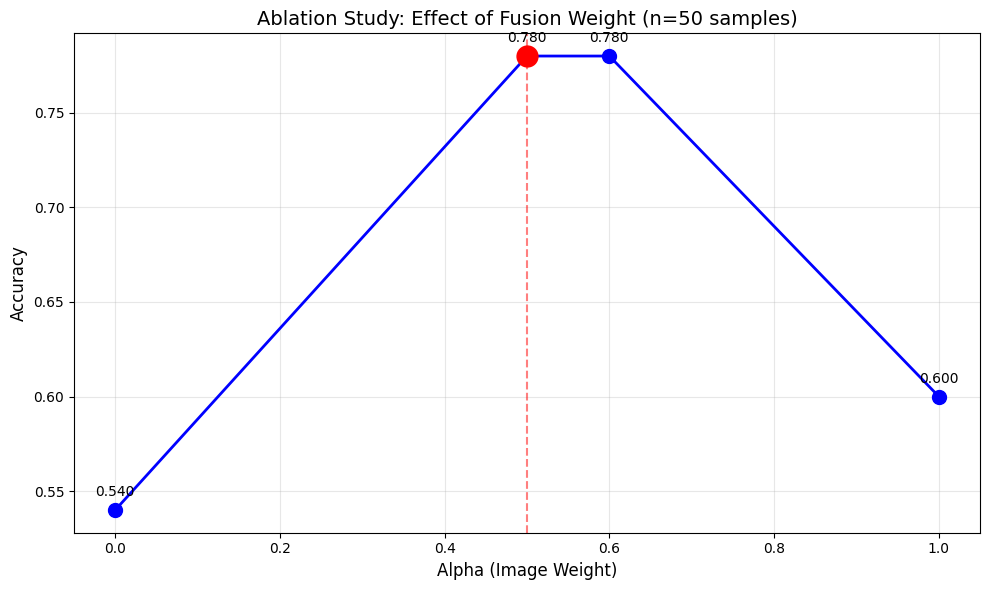


✅ Ablation results saved to ablation_results.json


In [22]:
# ============================================================
# CELL 19: QUICK ABLATION STUDY (Optimized)
# ============================================================

def run_ablation_quick(
    samples: List[Dict],
    alpha_values: List[float] = None,
    n_samples: int = 50,
    max_tokens: int = 128
) -> Dict:
    """
    Quick ablation study comparing different fusion weights.

    Args:
        samples: Validation samples
        alpha_values: List of alpha values to test
        n_samples: Number of samples to use (default: 50)
        max_tokens: Max tokens for generation (default: 128)

    Returns:
        Dictionary of results per alpha
    """

    if alpha_values is None:
        alpha_values = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]

    print(f"\n{'='*60}")
    print(f"QUICK ABLATION STUDY")
    print(f"{'='*60}")
    print(f"Samples: {n_samples} (from validation set)")
    print(f"Alphas: {alpha_values}")
    print(f"Max tokens: {max_tokens}")
    print(f"{'='*60}\n")

    results = {}

    for alpha in alpha_values:
        print(f"Testing alpha = {alpha:.2f}")
        correct = 0
        total = 0

        # Progress bar for current alpha
        pbar = tqdm(samples[:n_samples], desc=f"α={alpha:.2f}")

        for s in pbar:
            img = load_slake_image(s["img_name"])
            if img is None:
                continue

            # Generate answer with current alpha
            pred = rag_answer(
                query_text=s["question"],
                query_image=img,
                alpha=alpha,
                max_new_tokens=max_tokens,
                verbose=False,
            )

            # Check if correct (flexible matching)
            gt = str(s["answer"]).strip().lower()
            pred_lower = pred.strip().lower()

            # Multiple matching strategies
            is_correct = False
            if gt in pred_lower or pred_lower in gt:
                is_correct = True
            elif any(word in pred_lower for word in gt.split()):
                is_correct = True

            if is_correct:
                correct += 1
            total += 1

            # Update progress bar with current accuracy
            current_acc = correct / total if total > 0 else 0
            pbar.set_postfix({'acc': f'{current_acc:.3f}'})

        accuracy = correct / total if total > 0 else 0
        results[alpha] = {
            "accuracy": accuracy,
            "correct": correct,
            "total": total,
        }
        print(f"  ✅ α={alpha:.2f}: {accuracy:.4f} ({accuracy*100:.2f}%) - {correct}/{total}")
        print()

    return results

# ── Run Quick Ablation ──────────────────────────────────────────

print("🚀 Starting Quick Ablation Study...")

ablation_results = run_ablation_quick(
    samples=val_samples,           # Validation set
    alpha_values=[0.0, 0.5, 0.6, 1.0],  # Key alphas
    n_samples=50,                  # 50 samples (15-20 min)
    max_tokens=128,                # Shorter generation
)

# ── Display Results ─────────────────────────────────────────────

print("\n" + "="*60)
print("ABLATION STUDY RESULTS")
print("="*60)
print(f"{'Alpha':<10} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*60)

for alpha in sorted(ablation_results.keys()):
    res = ablation_results[alpha]
    print(f"{alpha:.2f}     {res['accuracy']:.4f} ({res['accuracy']*100:.2f}%)  {res['correct']}/{res['total']}")

# ── Find Best Alpha ─────────────────────────────────────────────

best_alpha = max(ablation_results, key=lambda x: ablation_results[x]["accuracy"])
best_acc = ablation_results[best_alpha]["accuracy"]

print("-"*60)
print(f"🏆 Best alpha: {best_alpha:.2f} with accuracy {best_acc:.4f} ({best_acc*100:.2f}%)")
print("="*60)

# ── Plot Results ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

alphas = sorted(ablation_results.keys())
accuracies = [ablation_results[a]["accuracy"] for a in alphas]

# Plot line
ax.plot(alphas, accuracies, 'o-', linewidth=2, markersize=10, color='blue')

# Highlight best
best_idx = alphas.index(best_alpha)
ax.plot(best_alpha, best_acc, 'o', markersize=15, color='red')
ax.axvline(x=best_alpha, color='red', linestyle='--', alpha=0.5)

# Add labels
ax.set_xlabel('Alpha (Image Weight)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'Ablation Study: Effect of Fusion Weight (n={ablation_results[best_alpha]["total"]} samples)', fontsize=14)
ax.grid(True, alpha=0.3)

# Add value labels
for a, acc in zip(alphas, accuracies):
    ax.annotate(f'{acc:.3f}',
                (a, acc),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center')

plt.tight_layout()
plt.show()

# ── Save Results ─────────────────────────────────────────────────

with open('/content/ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)
print("\n✅ Ablation results saved to ablation_results.json")

In [24]:
# ============================================================
# CELL 20: ERROR ANALYSIS
# ============================================================

def analyze_errors(
    predictions: List[Dict],
    error_types: List[str] = None,
    max_examples: int = 10
) -> Dict:
    """
    Analyze and categorize errors.
    """

    if error_types is None:
        error_types = [
            "retrieval_failure",
            "interpretation_failure",
            "question_understanding",
            "generation_error",
            "hallucination",
            "insufficient_context"
        ]

    errors = []

    for p in predictions:
        # Determine if prediction is correct
        gt = str(p["ground_truth"]).strip().lower()
        pred = str(p["prediction"]).strip().lower()

        is_correct = gt in pred or pred in gt

        if not is_correct:
            # Categorize error
            category = "unknown"
            pred_words = set(pred.split())

            # Check for specific error patterns
            if any(kw in pred for kw in ["don't know", "dont know", "cannot"]):
                category = "insufficient_context"
            elif "yes" in pred and "no" not in pred and gt == "no":
                category = "interpretation_failure"
            elif "no" in pred and "yes" not in pred and gt == "yes":
                category = "interpretation_failure"
            elif len(pred.split()) < 3:
                category = "generation_error"
            else:
                category = "unknown"

            errors.append({
                "question": p["question"],
                "ground_truth": p["ground_truth"],
                "prediction": p["prediction"],
                "answer_type": p["answer_type"],
                "content_type": p["content_type"],
                "category": category,
            })

    # Count by category
    error_counts = {}
    for e in errors:
        error_counts[e["category"]] = error_counts.get(e["category"], 0) + 1

    # Sort by frequency
    error_counts = dict(sorted(error_counts.items(), key=lambda x: -x[1]))

    return {
        "errors": errors[:max_examples],
        "error_counts": error_counts,
        "total_errors": len(errors),
        "error_rate": len(errors) / len(predictions) if predictions else 0,
    }

# Run error analysis
error_analysis = analyze_errors(test_predictions, max_examples=5)

print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)
print(f"Total predictions : {len(test_predictions)}")
print(f"Total errors      : {error_analysis['total_errors']}")
print(f"Error rate        : {error_analysis['error_rate']:.4f} ({error_analysis['error_rate']*100:.2f}%)")

print("\nError Categories:")
for cat, count in error_analysis['error_counts'].items():
    print(f"  {cat}: {count} ({count/error_analysis['total_errors']*100:.1f}%)" if error_analysis['total_errors'] > 0 else f"  {cat}: {count}")

print("\nExample Errors:")
for i, err in enumerate(error_analysis['errors'][:5]):
    print(f"\nError {i+1}:")
    print(f"  Question   : {err['question'][:80]}...")
    print(f"  Ground Truth: {err['ground_truth']}")
    print(f"  Prediction : {err['prediction']}")
    print(f"  Category   : {err['category']}")


ERROR ANALYSIS
Total predictions : 1061
Total errors      : 401
Error rate        : 0.3779 (37.79%)

Error Categories:
  unknown: 239 (59.6%)
  generation_error: 95 (23.7%)
  interpretation_failure: 59 (14.7%)
  insufficient_context: 8 (2.0%)

Example Errors:

Error 1:
  Question   : Which part of the body does this image belong to?...
  Ground Truth: Chest
  Prediction : Yes
  Category   : generation_error

Error 2:
  Question   : What is the main organ in the image?...
  Ground Truth: Lung, Spinal Cord
  Prediction : Based on the context provided, the image shows a close-up view of a person's chest, specifically focusing on the lungs. The lungs are the main organs in this image, as they are responsible for the exchange of oxygen and carbon dioxide in the body.
  Category   : unknown

Error 3:
  Question   : Does the picture contain heart?...
  Ground Truth: No
  Prediction : Yes
  Category   : interpretation_failure

Error 4:
  Question   : Where is/are the abnormality located?...
 

In [25]:
# ============================================================
# CELL 21: QUALITATIVE RESULTS
# ============================================================

def display_qualitative_results(
    predictions: List[Dict],
    n_examples: int = 4
):
    """Display qualitative examples from test set."""

    # Select examples
    closed_examples = [p for p in predictions if p["answer_type"] == "CLOSED"][:n_examples//2]
    open_examples = [p for p in predictions if p["answer_type"] == "OPEN"][:n_examples//2]

    examples = closed_examples + open_examples

    print("\n" + "="*60)
    print("QUALITATIVE RESULTS")
    print("="*60)

    for i, p in enumerate(examples, 1):
        # Determine if correct
        gt = str(p["ground_truth"]).strip().lower()
        pred = str(p["prediction"]).strip().lower()
        is_correct = gt in pred or pred in gt
        status = "✅ CORRECT" if is_correct else "❌ INCORRECT"

        print(f"\n--- Example {i} [{p['answer_type']}] {status} ---")
        print(f"Question      : {p['question']}")
        print(f"Ground Truth  : {p['ground_truth']}")
        print(f"Prediction    : {p['prediction']}")
        print(f"Content Type  : {p['content_type']}")
        print(f"Modality      : {p['modality']}")

# Display results
display_qualitative_results(test_predictions, n_examples=4)


QUALITATIVE RESULTS

--- Example 1 [CLOSED] ✅ CORRECT ---
Question      : Does the picture contain liver?
Ground Truth  : No
Prediction    : No
Content Type  : Organ
Modality      : CT

--- Example 2 [CLOSED] ✅ CORRECT ---
Question      : Does the picture contain lung?
Ground Truth  : Yes
Prediction    : Yes
Content Type  : Organ
Modality      : CT

--- Example 3 [OPEN] ✅ CORRECT ---
Question      : What modality is used to take this image?
Ground Truth  : CT
Prediction    : The image shows a CT scan of a person's chest and lungs, providing a detailed view of the internal organs. The lungs are clearly visible, with the right lung occupying a larger portion of the image compared to the left lung. The heart can also be seen within the chest area. The CT scan provides valuable information for medical professionals to diagnose and treat various health conditions related to the lungs and heart.
Content Type  : Modality
Modality      : CT

--- Example 4 [OPEN] ❌ INCORRECT ---
Question      

In [27]:
# ============================================================
# CELL 22: FINAL RESULTS SUMMARY
# ============================================================

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

# Build summary table
summary = {
    "Dataset": {
        "Knowledge Base (Train)": f"{len(kb_samples):,}",
        "Validation (Dev)": f"{len(val_samples):,}",
        "Test (Final Eval)": f"{len(test_samples):,}",
    },
    "Closed QA": {
        "Samples": f"{closed_results['n_samples'] if closed_results else 0}",
        "Accuracy": f"{closed_results['accuracy']*100:.2f}%" if closed_results else "N/A",
        "Precision": f"{closed_results['precision']:.4f}" if closed_results else "N/A",
        "Recall": f"{closed_results['recall']:.4f}" if closed_results else "N/A",
        "F1 Score": f"{closed_results['f1']:.4f}" if closed_results else "N/A",
    },
    "Open QA (BERTScore)": {
        "Samples": f"{open_results['n_samples'] if open_results else 0}",
        "Precision": f"{open_results['precision']:.4f}" if open_results else "N/A",
        "Recall": f"{open_results['recall']:.4f}" if open_results else "N/A",
        "F1 Score": f"{open_results['f1']:.4f}" if open_results else "N/A",
    },
    "OOD Evaluation": {
        "Samples": f"{ood_results['n_samples'] if ood_results else 0}",
        "Abstention Rate": f"{ood_results['abstention_rate']*100:.2f}%" if ood_results else "N/A",
        "Hallucination Rate": f"{ood_results['hallucination_rate']*100:.2f}%" if ood_results else "N/A",
    },
    "Retrieval (Validation)": {
        **{k: f"{v*100:.2f}%" for k, v in val_retrieval_results.items()},
    },
    "Best Alpha (Validation)": {
        "Alpha": f"{best_alpha:.2f}",
        "Accuracy": f"{best_acc*100:.2f}%" if best_acc else "N/A",
    },
}

# Display as table
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)

for category, metrics in summary.items():
    print(f"\n{category}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value}")




FINAL RESULTS SUMMARY

SUMMARY TABLE

Dataset:
  Knowledge Base (Train): 4,918
  Validation (Dev): 1,053
  Test (Final Eval): 1,061

Closed QA:
  Samples: 416
  Accuracy: 73.56%
  Precision: 0.7152
  Recall: 0.7356
  F1 Score: 0.7197

Open QA (BERTScore):
  Samples: 645
  Precision: 0.8183
  Recall: 0.8545
  F1 Score: 0.8356

OOD Evaluation:
  Samples: 0
  Abstention Rate: N/A
  Hallucination Rate: N/A

Retrieval (Validation):
  Recall@1: 100.00%
  Recall@3: 100.00%
  Recall@5: 100.00%
  Recall@10: 100.00%

Best Alpha (Validation):
  Alpha: 0.50
  Accuracy: 78.00%


In [28]:
# ============================================================
# CELL 23: PATIENT DASHBOARD (INTERACTIVE DEMO)
# ============================================================

class PatientImageHandler:
    """Handles patient medical image upload and management."""

    def __init__(self):
        self.current_image = None
        self.current_image_path = None
        self.image_history = []

        self.uploader = widgets.FileUpload(
            accept='image/*',
            multiple=False,
            description='Upload Patient Image',
            button_style='primary'
        )

        self.image_display = widgets.Output()
        self.clear_btn = widgets.Button(
            description='Clear Image',
            button_style='warning',
            icon='trash'
        )

        self.uploader.observe(self.on_image_upload, names='value')
        self.clear_btn.on_click(self.clear_image)

        self.info_label = widgets.HTML(
            value="<b>No image uploaded yet. Please upload a patient medical image.</b>"
        )

    def on_image_upload(self, change):
        if not self.uploader.value:
            return

        with self.image_display:
            self.image_display.clear_output()

            uploaded_filename = next(iter(self.uploader.value))
            file_info = self.uploader.value[uploaded_filename]
            content = file_info['content']

            self.current_image = Image.open(BytesIO(content)).convert("RGB")
            self.current_image_path = uploaded_filename

            if self.current_image.size != (336, 336):
                self.current_image = self.current_image.resize((336, 336), Image.Resampling.LANCZOS)

            self.image_history.append({
                'name': self.current_image_path,
                'image': self.current_image.copy(),
            })

            display(HTML(f"<h4>Patient Image: {self.current_image_path}</h4>"))
            display(self.current_image)
            display(HTML(f"<p><b>Image Size:</b> {self.current_image.size}</p>"))

            self.info_label.value = f"✅ <b>Image loaded:</b> {self.current_image_path} | Size: {self.current_image.size}"

    def clear_image(self, b):
        with self.image_display:
            self.image_display.clear_output()
            self.current_image = None
            self.current_image_path = None
            self.info_label.value = "<b>No image uploaded. Please upload a patient medical image.</b>"
            display(HTML("<i>Image cleared. Upload a new patient image to proceed.</i>"))

    def get_current_image(self):
        return self.current_image

    def get_upload_widget(self):
        return widgets.VBox([
            self.uploader,
            self.clear_btn,
            self.info_label,
            self.image_display
        ])

# Initialize
patient_handler = PatientImageHandler()

# Diagnostic questions
diagnostic_questions = {
    "Abnormality Detection (Yes/No)": "Is there any abnormality visible in this medical image?",
    "Organ Identification": "What organ or body part is shown in this medical image?",
    "Modality Type": "What type of medical imaging is this (X-ray, CT, MRI, Ultrasound, etc.)?",
    "Finding Description": "Please describe the key findings visible in this medical image.",
    "Abnormality Description": "What abnormalities do you see in this image? Please describe them.",
    "Differential Diagnosis": "Based on the findings, what are the potential diagnoses?",
    "Severity Assessment": "How severe do the findings appear?",
    "Location Description": "Where exactly is the abnormality located?",
    "Comparison to Normal": "How does this image differ from normal anatomy?",
}

# Question widgets
question_dropdown = widgets.Dropdown(
    options=list(diagnostic_questions.keys()),
    description='Quick Questions:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

custom_question = widgets.Textarea(
    placeholder="Or type your own medical question here...\n\nExamples:\n- 'Describe the lung fields in detail.'\n- 'What is the cardiac silhouette size?'\n- 'Please describe the bone structures.'",
    description='Custom Question:',
    layout=widgets.Layout(width='90%', height='120px')
)

length_selector = widgets.Dropdown(
    options=[
        ('Concise (1-2 sentences)', 128),
        ('Moderate (2-4 sentences)', 256),
        ('Detailed (4-6 sentences)', 384),
        ('Very Detailed (6-8 sentences)', 512)
    ],
    description='Answer Length:',
    value=256,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

diagnose_btn = widgets.Button(
    description="🔍 Analyze Patient Image",
    button_style='success',
    icon='stethoscope',
    layout=widgets.Layout(width='auto')
)

diagnosis_output = widgets.Output()
status_indicator = widgets.HTML(value="<i>Ready. Please upload a patient image and ask a question.</i>")

def on_analyze(b):
    with diagnosis_output:
        clear_output()

        patient_img = patient_handler.get_current_image()
        if patient_img is None:
            display(HTML(
                "<div style='background-color: #ffcccc; padding: 15px; border-radius: 5px;'>"
                "❌ <b>Error:</b> No patient image uploaded. Please upload a medical image first."
                "</div>"
            ))
            return

        if custom_question.value.strip():
            question = custom_question.value.strip()
        else:
            question = diagnostic_questions[question_dropdown.value]

        max_tokens = length_selector.value
        q_type = detect_question_type(question)
        q_type_label = "📝 DESCRIPTIVE" if q_type == "descriptive" else "✅ YES/NO"

        # Analyzing message
        display(HTML(
            f"<div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); "
            f"padding: 15px; border-radius: 10px; margin-bottom: 15px;'>"
            f"<div style='display: flex; align-items: center; gap: 10px;'>"
            f"<span style='font-size: 24px;'>🩺</span>"
            f"<span style='color: white; font-weight: bold;'>ANALYZING PATIENT IMAGE</span>"
            f"<span style='background-color: #ffd700; color: #333; padding: 2px 8px; border-radius: 12px; font-size: 12px;'>{q_type_label}</span>"
            f"</div>"
            f"<div style='margin-top: 10px;'>"
            f"<span style='color: #ffd700;'>📷 Image:</span> <span style='color: white;'>{patient_handler.current_image_path}</span><br>"
            f"<span style='color: #ffd700;'>❓ Question:</span> <span style='color: white;'>{question}</span><br>"
            f"<span style='color: #87ceeb; font-style: italic;'>⏳ Processing... This may take a few seconds.</span>"
            f"</div>"
            f"</div>"
        ))

        try:
            answer = rag_answer(
                query_text=question,
                query_image=patient_img,
                max_new_tokens=max_tokens,
                verbose=True,
            )

            # Display result
            result_bg = "#d4edda" if q_type != "descriptive" else "#d1ecf1"
            result_border = "#28a745" if q_type != "descriptive" else "#17a2b8"
            answer_color = "#155724" if q_type != "descriptive" else "#0c5460"

            display(HTML(
                f"<div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); "
                f"padding: 20px; border-radius: 10px; margin-top: 15px;'>"
                f"<div style='background-color: white; padding: 20px; border-radius: 8px;'>"
                f"<h3 style='color: #2c3e50; margin-top: 0; border-bottom: 2px solid #667eea; padding-bottom: 10px;'>"
                f"📋 Diagnosis Result"
                f"</h3>"
                f"<div style='margin: 15px 0;'>"
                f"<span style='color: #34495e; font-weight: bold;'>❓ QUESTION TYPE:</span><br>"
                f"<span style='color: #2c3e50;'>{q_type_label}</span>"
                f"</div>"
                f"<div style='margin: 15px 0;'>"
                f"<span style='color: #34495e; font-weight: bold;'>❓ QUESTION:</span><br>"
                f"<span style='color: #2c3e50; font-size: 16px;'>{question}</span>"
                f"</div>"
                f"<div style='margin: 15px 0; background-color: {result_bg}; padding: 15px; border-radius: 8px; border-left: 4px solid {result_border};'>"
                f"<span style='color: #27ae60; font-weight: bold;'>✅ ANSWER:</span><br>"
                f"<span style='color: {answer_color}; font-size: 16px; line-height: 1.6;'>{answer}</span>"
                f"</div>"
                f"<div style='margin-top: 10px; text-align: right;'>"
                f"<span style='color: #95a5a6; font-size: 12px;'>Powered by Medical RAG System | LLaVA-1.5-7B</span>"
                f"</div>"
                f"</div>"
                f"</div>"
            ))

            status_indicator.value = "✅ Analysis completed successfully."

        except Exception as e:
            display(HTML(
                f"<div style='background-color: #ffcccc; padding: 15px; border-radius: 5px;'>"
                f"❌ <b>Error during analysis:</b> {str(e)}<br>"
                f"Please check your image and try again."
                f"</div>"
            ))
            status_indicator.value = f"❌ Error: {str(e)[:100]}"

diagnose_btn.on_click(on_analyze)

# Build dashboard
dashboard = widgets.VBox([
    widgets.HTML("""
        <div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                    padding: 20px; border-radius: 10px; margin-bottom: 20px;'>
            <h2 style='color: white; margin: 0;'>🏥 Patient Medical Image Diagnosis System</h2>
            <p style='color: #e2e8f0; margin: 10px 0 0 0;'>
                Upload a patient's medical image and ask clinical questions.
                The system retrieves similar cases from the medical knowledge base
                and provides AI-powered analysis.
            </p>
            <p style='color: #ffd700; margin: 10px 0 0 0; font-size: 14px;'>
                💡 Tip: Use descriptive questions like "Describe..." or "What..." for detailed answers!
            </p>
        </div>
    """),
    widgets.HBox([
        widgets.VBox([
            widgets.HTML("<h3 style='color: #e67e22;'>📤 Step 1: Upload Patient Image</h3>"),
            patient_handler.get_upload_widget()
        ], layout=widgets.Layout(width='40%')),
        widgets.VBox([
            widgets.HTML("<h3 style='color: #3498db;'>❓ Step 2: Ask Question</h3>"),
            question_dropdown,
            custom_question,
            widgets.HBox([length_selector, diagnose_btn], layout=widgets.Layout(justify_content='space-between')),
            status_indicator
        ], layout=widgets.Layout(width='55%'))
    ]),
    widgets.HTML("<hr style='border: 1px solid #cbd5e0; margin: 20px 0;'>"),
    widgets.HTML("<h3 style='color: #27ae60; font-size: 24px; font-weight: bold;'>📋 Step 3: Diagnosis Result</h3>"),
    diagnosis_output
])

display(dashboard)
print("\nDashboard ready! Upload an image and ask a question to get started.")


Dashboard ready! Upload an image and ask a question to get started.
